In [1]:
import os
import sys
import IPython
import IPython.display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import collections
from numpy import reshape, array
from datetime import datetime, timedelta

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv1D,Dense
from tensorflow.keras import layers

cell_type = "lg"
model_type = "dnn_model"
base_path = '../../'

sys.path.append(base_path)
from training import utils

lg_data_path = base_path + 'datasets/Dataset_Li-ion'
pre_trained_path = base_path + 'pre-trained/' + cell_type + '_' + model_type

resample_1hz = True
vi_averages = True

In [2]:
lg_charge_cycles = ['Charge']

lg_train_temps = ['n10degC', '0degC', '10degC', '25degC']
lg_train_discharge_cycles = ['Mixed']

lg_test_temps = ['n10degC', '0degC', '10degC', '25degC']
lg_test_discharge_cycles = ['UDDS', 'HWFET', 'LA92', 'US06']

lg_train_files = utils.lg_get_files(lg_data_path, 
                                    lg_train_discharge_cycles, 
                                    lg_charge_cycles, 
                                    lg_train_temps)

lg_test_files = utils.lg_get_files(lg_data_path, 
                                   lg_test_discharge_cycles,
                                   lg_charge_cycles, 
                                   lg_test_temps)

lg_train, lg_train_norm = utils.lg_create_dataset(lg_train_files, 
                                                  lg_train_discharge_cycles, 
                                                  lg_charge_cycles, 
                                                  vi_averages, 
                                                  resample_1hz)

lg_test, lg_test_norm = utils.lg_create_dataset(lg_test_files, 
                                                lg_test_discharge_cycles, 
                                                lg_charge_cycles, 
                                                vi_averages, 
                                                resample_1hz)

E:\AI-ML-Based-Battery-Management-System-for-EVs-main\AI-ML-Based-Battery-Management-System-for-EVs-main\soc\dnn\../..\training\utils.py:63: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(csv_file, header=[25,26], index_col=0, parse_dates=True, nrows=26)
E:\AI-ML-Based-Battery-Management-System-for-EVs-main\AI-ML-Based-Battery-Management-System-for-EVs-main\soc\dnn\../..\training\utils.py:63: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(csv_file, header=[25,26], index_col=0, parse_dates=True, nrows=26)
E:\AI-ML-Based-Battery-Management-System-for-EVs-main\AI-ML-Based-Battery-Management-System-for-EVs-main\soc\dnn\../..\training\utils.py:63: UserWarning: Could not infer format, 

../../datasets/Dataset_Li-ion/25degC/551_Mixed1.csv 77227


E:\AI-ML-Based-Battery-Management-System-for-EVs-main\AI-ML-Based-Battery-Management-System-for-EVs-main\soc\dnn\../..\training\utils.py:134: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cycle = pd.read_csv(path, header=[25,26], index_col=0, parse_dates=True)


../../datasets/Dataset_Li-ion/25degC/551_Mixed2.csv 79172
../../datasets/Dataset_Li-ion/25degC/552_Mixed3.csv 73827
../../datasets/Dataset_Li-ion/25degC/552_Mixed4.csv 80850


E:\AI-ML-Based-Battery-Management-System-for-EVs-main\AI-ML-Based-Battery-Management-System-for-EVs-main\soc\dnn\../..\training\utils.py:134: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cycle = pd.read_csv(path, header=[25,26], index_col=0, parse_dates=True)


...

../../datasets/Dataset_Li-ion/0degC/589_LA92.csv 81577


E:\AI-ML-Based-Battery-Management-System-for-EVs-main\AI-ML-Based-Battery-Management-System-for-EVs-main\soc\dnn\../..\training\utils.py:134: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cycle = pd.read_csv(path, header=[25,26], index_col=0, parse_dates=True)


../../datasets/Dataset_Li-ion/0degC/589_US06.csv 33806


E:\AI-ML-Based-Battery-Management-System-for-EVs-main\AI-ML-Based-Battery-Management-System-for-EVs-main\soc\dnn\../..\training\utils.py:134: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cycle = pd.read_csv(path, header=[25,26], index_col=0, parse_dates=True)


../../datasets/Dataset_Li-ion/n10degC/596_UDDS.csv 123602
../../datasets/Dataset_Li-ion/n10degC/596_HWFET.csv 44903
../../datasets/Dataset_Li-ion/n10degC/596_LA92.csv 72098
../../datasets/Dataset_Li-ion/n10degC/601_US06.csv 31913


# Train and Test datasets 

## Train :

In [3]:
lg_train.describe()


Time Stamp,Voltage,Current,Temperature,Power,Capacity,Voltage Average,Current Average,Power Average
count,176334.000000,176334.000000,176334.000000,176334.000000,176334.000000,176334.000000,176334.000000,176334.000000
mean,3.665063,-1.333758,7.891981,-4.596105,0.485778,3.699654,-1.296481,-4.522300
std,0.262172,2.561152,12.526156,8.941956,0.267832,0.226606,0.711963,2.410210
min,2.792680,-17.822440,-9.884900,-50.862673,0.000000,3.094354,-3.715850,-11.429077
25%,3.494900,-2.556640,-0.315480,-9.210683,0.269070,3.521361,-1.720026,-5.996818
50%,3.672220,-0.950120,9.359110,-3.477834,0.473796,3.694212,-1.162827,-4.127167
75%,3.859490,-0.097060,23.976150,-0.386161,0.715691,3.889611,-0.772447,-2.722423
max,4.200630,5.999610,26.289630,25.171220,0.978056,4.139058,-0.277316,-1.079428


## Test :


In [4]:
lg_test.describe()


Time Stamp,Voltage,Current,Temperature,Power,Capacity,Voltage Average,Current Average,Power Average
count,104485.000000,104485.000000,104485.000000,104485.000000,104485.000000,104485.000000,104485.000000,104485.000000
mean,3.677951,-1.098654,6.921388,-3.776420,0.484375,3.704737,-1.097331,-3.824287
std,0.261341,2.357463,12.063139,8.243404,0.267702,0.229296,0.728330,2.439860
min,2.794030,-17.610450,-10.095220,-50.864924,0.000000,3.049658,-3.810095,-11.887300
25%,3.496920,-2.191410,-0.420630,-7.916661,0.258278,3.523629,-1.335683,-4.544482
50%,3.689080,-0.625750,9.148790,-2.317480,0.494788,3.716103,-0.867386,-3.073238
75%,3.885750,-0.084280,23.765830,-0.316026,0.714165,3.900654,-0.523847,-1.888219
max,4.200120,5.999610,26.815430,25.142453,0.955909,4.110299,-0.311306,-1.210706


In [5]:
lg_train

Time Stamp,Voltage,Current,Temperature,Power,Capacity,Voltage Average,Current Average,Power Average
0,4.11924,-0.18645,23.87099,-0.768032,0.972001,4.133085,-0.523572,-2.132373
1,4.11317,-0.47251,23.87099,-1.943514,0.971967,4.132942,-0.524415,-2.135832
2,4.10626,-0.76878,23.87099,-3.156811,0.971905,4.132788,-0.525768,-2.141377
3,4.09547,-1.23107,23.87099,-5.041810,0.971801,4.132612,-0.528041,-2.150670
4,4.11014,-0.49549,23.87099,-2.036533,0.971700,4.132466,-0.528838,-2.153931
...,...,...,...,...,...,...,...,...
176329,2.91961,-2.96785,-8.51784,-8.664965,0.002039,3.334978,-1.083477,-3.225658
176330,2.81662,-5.79012,-8.51784,-16.308568,0.001575,3.334203,-1.089342,-3.239959
176331,2.95129,-1.12125,-8.51784,-3.309134,0.000977,3.333552,-1.087911,-3.234542
176332,2.84241,-6.55635,-8.51784,-18.635835,0.000764,3.332554,-1.098112,-3.262086


In [6]:
lg_test

Time Stamp,Voltage,Current,Temperature,Power,Capacity,Voltage Average,Current Average,Power Average
0,4.17113,2.55922,23.97615,10.674839,0.954944,4.110299,-0.845544,-3.395760
1,4.17669,2.75078,23.97615,11.489155,0.955238,4.110283,-0.839941,-3.372355
2,4.16776,2.26039,23.97615,9.420763,0.955485,4.110252,-0.835226,-3.352701
3,4.15326,1.54779,23.97615,6.428374,0.955655,4.110193,-0.831936,-3.339032
4,4.14652,1.23108,23.97615,5.104698,0.955790,4.110120,-0.829280,-3.328011
...,...,...,...,...,...,...,...,...
104480,3.21807,1.80831,-6.30951,5.819268,0.001352,3.100237,-2.803562,-7.848327
104481,3.17677,0.03065,-6.30951,0.097368,0.001526,3.100945,-2.783114,-7.790577
104482,2.98787,-4.46455,-6.30951,-13.339495,0.001380,3.101158,-2.777138,-7.774308
104483,3.28010,3.00108,-6.30951,9.843843,0.001089,3.101938,-2.757206,-7.714365


In [7]:
lg_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 176334 entries, 0 to 176333
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Voltage          176334 non-null  float64
 1   Current          176334 non-null  float64
 2   Temperature      176334 non-null  float64
 3   Power            176334 non-null  float64
 4   Capacity         176334 non-null  float64
 5   Voltage Average  176334 non-null  float64
 6   Current Average  176334 non-null  float64
 7   Power Average    176334 non-null  float64
dtypes: float64(8)
memory usage: 10.8 MB


In [8]:
lg_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 104485 entries, 0 to 104484
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Voltage          104485 non-null  float64
 1   Current          104485 non-null  float64
 2   Temperature      104485 non-null  float64
 3   Power            104485 non-null  float64
 4   Capacity         104485 non-null  float64
 5   Voltage Average  104485 non-null  float64
 6   Current Average  104485 non-null  float64
 7   Power Average    104485 non-null  float64
dtypes: float64(8)
memory usage: 6.4 MB


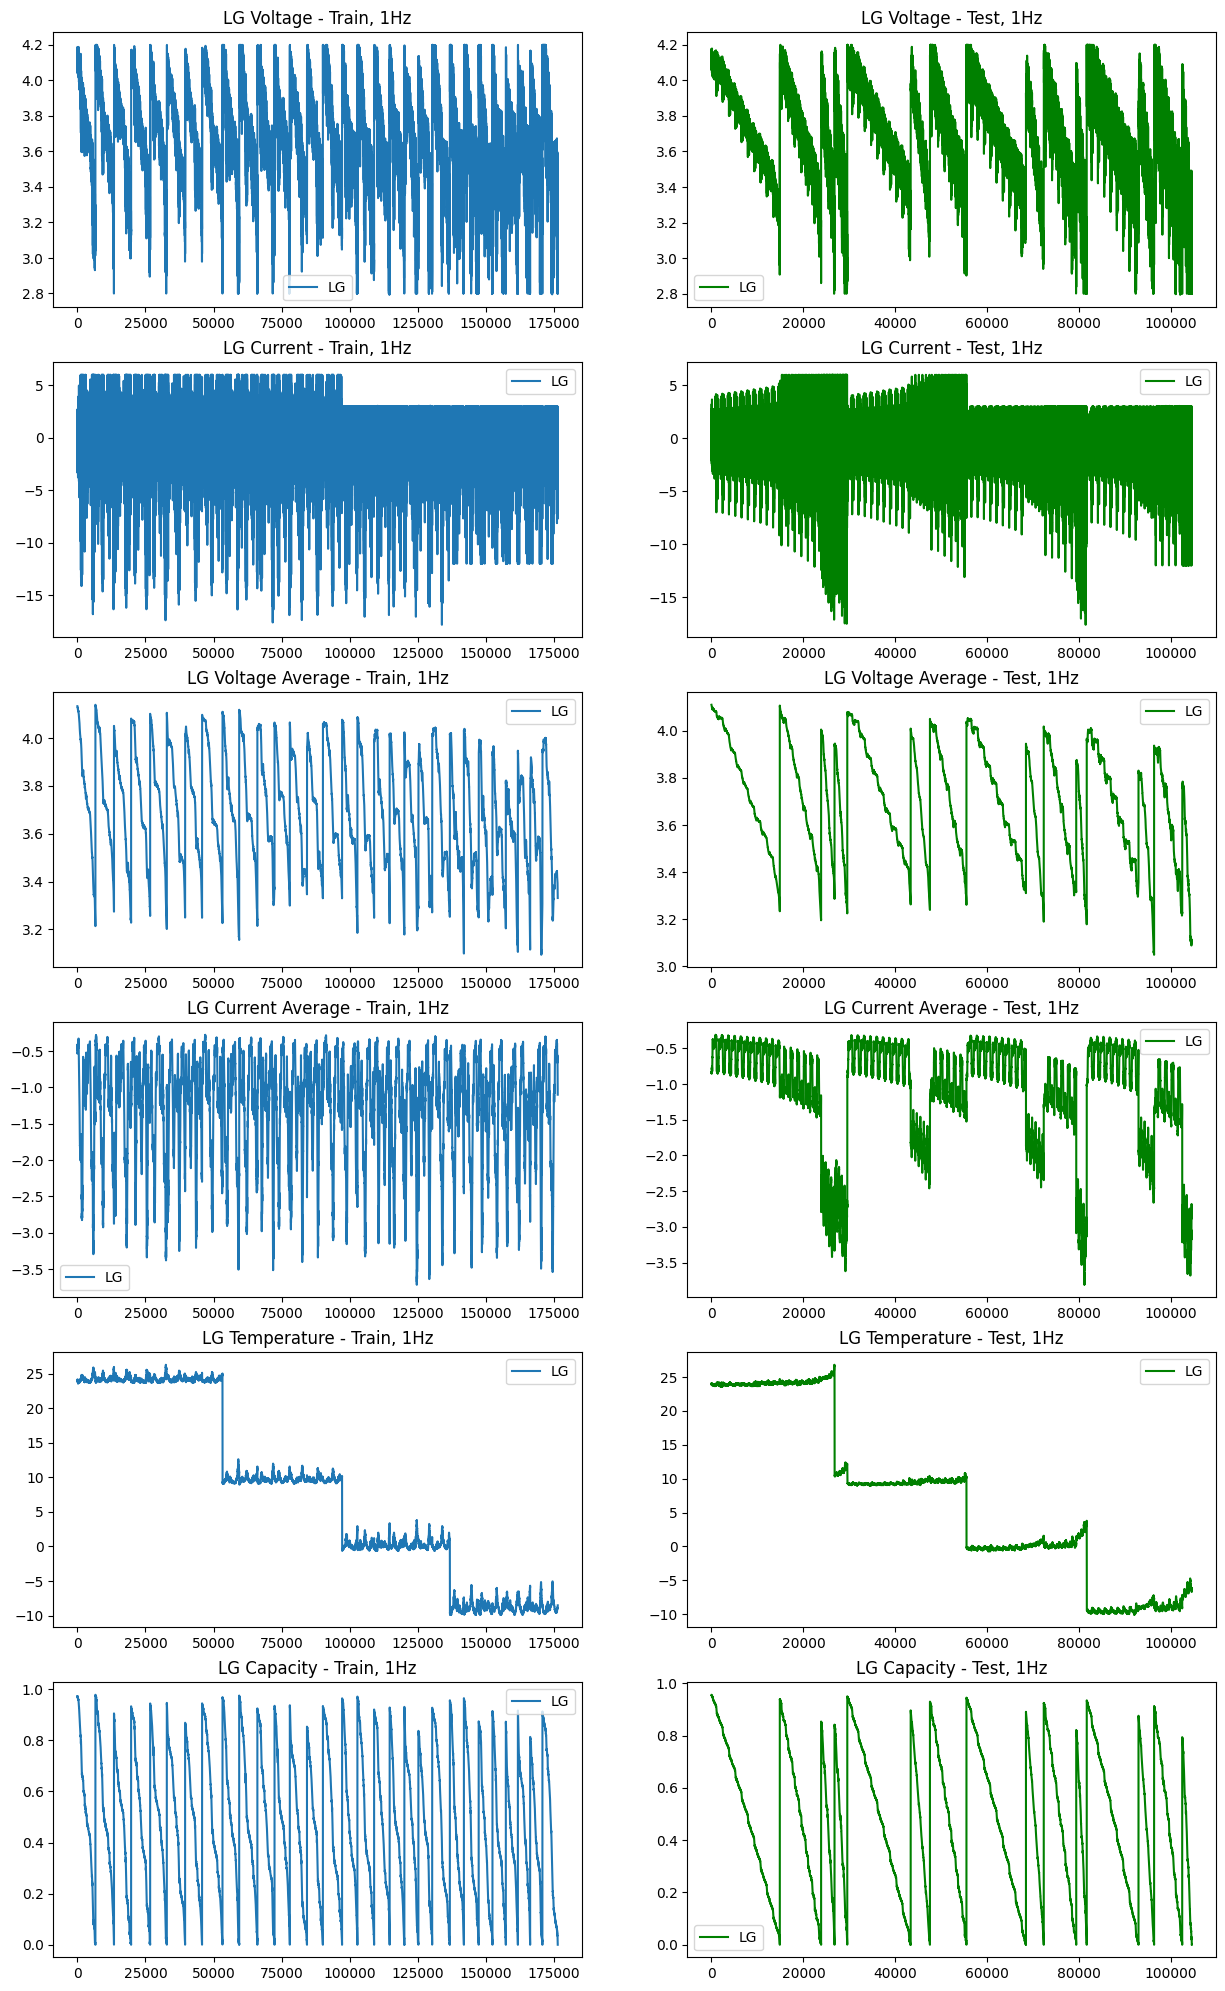

In [9]:
plot_cols = ['Voltage', 'Current', 'Voltage Average', 'Current Average', 'Temperature', 'Capacity']

fig, axs = plt.subplots(nrows=len(plot_cols), ncols=2, figsize=(15, 25))

for i, col in enumerate(plot_cols):
    axs[i, 0].plot(lg_train[col], label='LG')
    axs[i, 0].set_title(f'LG {col} - Train, 1Hz')
    axs[i, 0].legend()
    
    axs[i, 1].plot(lg_test[col], label='LG', color="green")
    axs[i, 1].set_title(f'LG {col} - Test, 1Hz')
    axs[i, 1].legend()

C:\Users\asus\AppData\Local\Temp\ipykernel_17488\3865369826.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(lg_train.keys(), rotation=90)


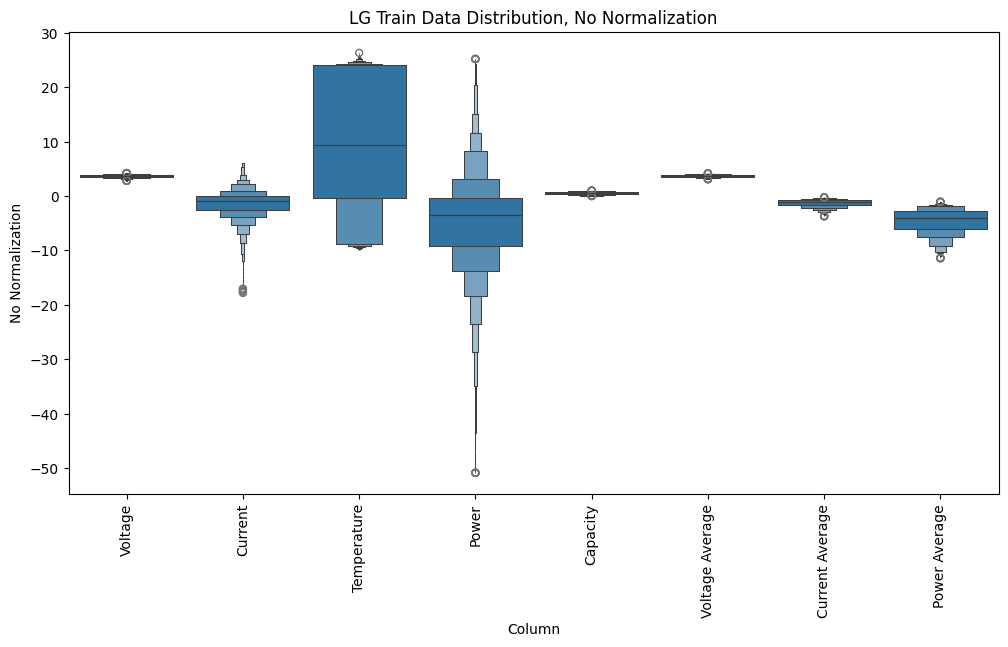

In [10]:
# Melt the DataFrame for seaborn compatibility
df_std = lg_train.melt(var_name='Column', value_name='No Normalization')

# Create a figure for the boxen plot
plt.figure(figsize=(12, 6))

# Create the boxen plot
ax = sns.boxenplot(x='Column', y='No Normalization', data=df_std)

# Set the x-tick labels with a rotation for better readability
ax.set_xticklabels(lg_train.keys(), rotation=90)

# Set the title of the plot
ax.set_title(label='LG Train Data Distribution, No Normalization')

# Display the plot
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_17488\4262262070.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(lg_train.columns, rotation=90)


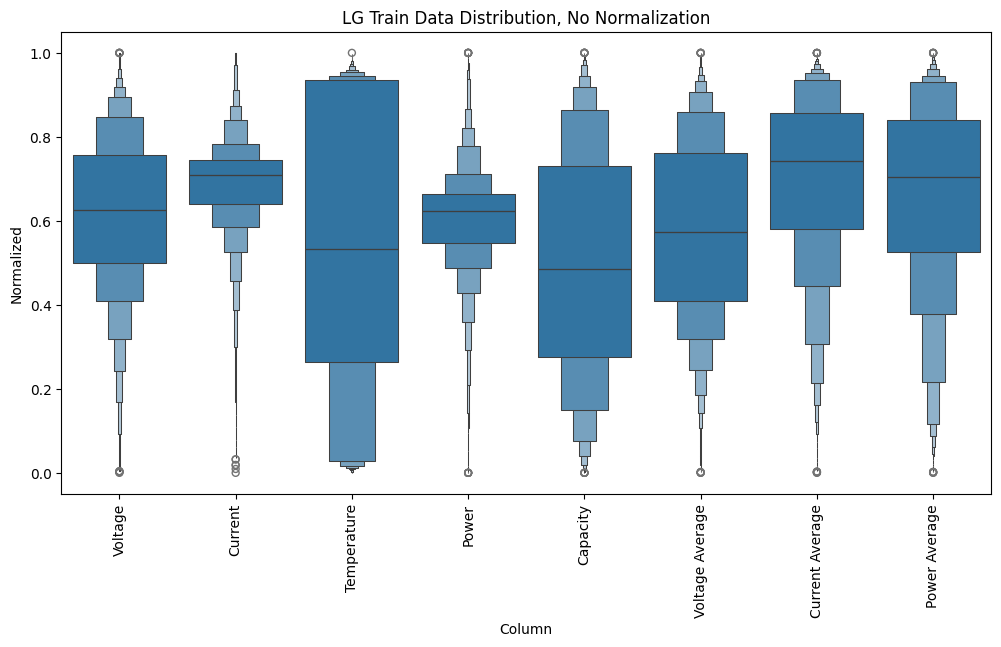

In [11]:
# Melt the DataFrame for seaborn compatibility
df_std = lg_train_norm.melt(var_name='Column', value_name='Normalized')

# Create a figure for the boxen plot
plt.figure(figsize=(12, 6))

# Create the boxen plot
ax = sns.boxenplot(x='Column', y='Normalized', data=df_std)

# Set the x-tick labels with a rotation for better readability
ax.set_xticklabels(lg_train.columns, rotation=90)

# Set the title of the plot
ax.set_title(label='LG Train Data Distribution, No Normalization')

# Display the plot
plt.show()

Text(0.5, 1.01, 'Pair Plot, LG Training Dataset')

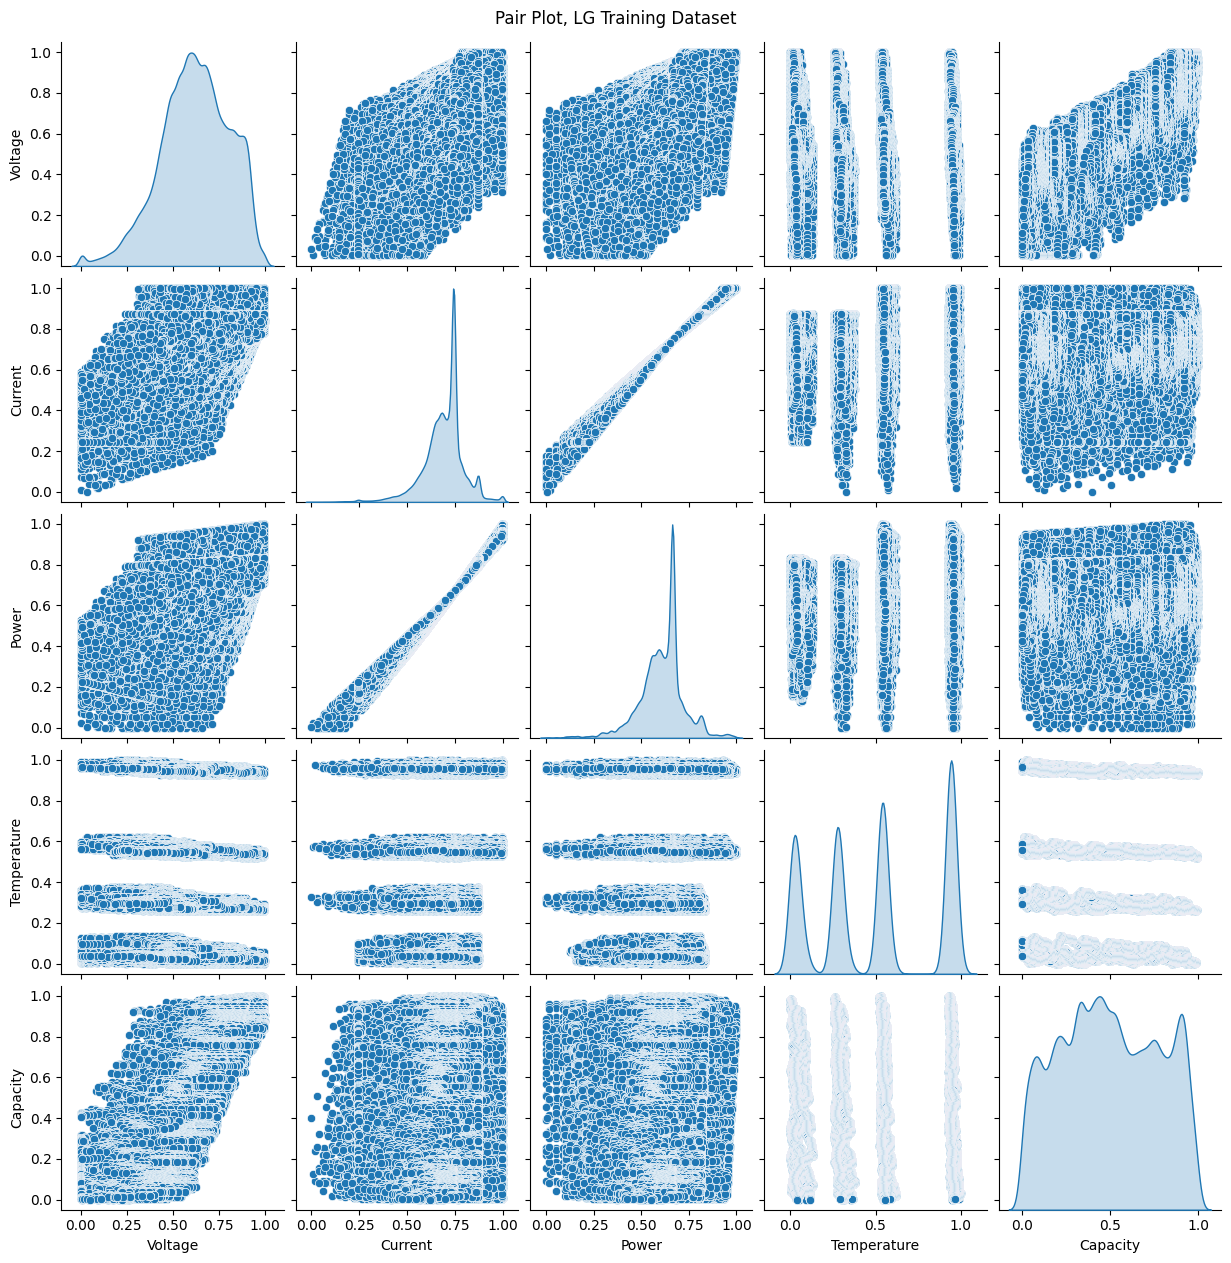

In [12]:
ax = sns.pairplot(lg_train_norm[['Voltage', 'Current', 'Power', 'Temperature', 'Capacity']], diag_kind='kde')
ax.fig.suptitle("Pair Plot, LG Training Dataset", y = 1.01) 

# DNN implementation


In [13]:
train_features = lg_train_norm
test_features = lg_test_norm

train_labels = train_features.pop('Capacity')
test_labels = test_features.pop('Capacity')

In [14]:
train_labels

0         0.993809
1         0.993773
2         0.993710
3         0.993604
4         0.993501
            ...   
176329    0.002085
176330    0.001610
176331    0.000999
176332    0.000781
176333    0.000126
Name: Capacity, Length: 176334, dtype: float64

In [15]:
dnn_model = tf.keras.Sequential([
      layers.Dense(64, activation='relu', input_shape=(train_features.shape[1],)),
      layers.Dense(64, activation='relu'),
      layers.Dense(1)
      ])

dnn_model.compile(loss='mean_absolute_error', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=['mse', 'mae', 'mape', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

dnn_model.summary()

C:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
%%time
history = dnn_model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    verbose=1, epochs=25)

Epoch 1/25
4409/4409 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 0.0151 - mae: 0.0151 - mape: 15.3806 - mse: 5.0600e-04 - rmse: 0.0225 - val_loss: 0.0333 - val_mae: 0.0333 - val_mape: 2578.2827 - val_mse: 0.0015 - val_rmse: 0.0391
Epoch 2/25
4409/4409 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 0.0106 - mae: 0.0106 - mape: 9.2855 - mse: 1.8873e-04 - rmse: 0.0137 - val_loss: 0.0153 - val_mae: 0.0153 - val_mape: 810.8511 - val_mse: 4.3859e-04 - val_rmse: 0.0209
Epoch 3/25
4409/4409 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 0.0095 - mae: 0.0095 - mape: 7.7971 - mse: 1.5579e-04 - rmse: 0.0125 - val_loss: 0.0157 - val_mae: 0.0157 - val_mape: 182.5757 - val_mse: 4.6307e-04 - val_rmse: 0.0215
Epoch 4/25
4409/4409 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 0.0090 - mae: 0.0090 - mape: 7.1213 - mse: 1.4180e-04 - rmse: 0.0119 - val_loss: 0.0195 - val_mae: 0.0195 - val_mape: 546.8865 - val_mse: 6.9290e-04 - val_rmse: 0.0263
Epoch 5/25
4409/4409 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 0.0087 - mae: 0

In [17]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()


,loss,mae,mape,mse,rmse,val_loss,val_mae,val_mape,val_mse,val_rmse,epoch
20,0.007222,0.007222,4.594524,0.000100,0.009985,0.018469,0.018469,534.270569,0.000645,0.025400,20
21,0.007150,0.007150,5.037853,0.000098,0.009909,0.017656,0.017656,514.003357,0.000570,0.023882,21
22,0.007148,0.007148,5.063876,0.000098,0.009906,0.018550,0.018550,771.519836,0.000632,0.025133,22
23,0.007120,0.007120,4.831915,0.000097,0.009857,0.018448,0.018448,584.168640,0.000666,0.025801,23
24,0.007059,0.007059,5.233938,0.000096,0.009815,0.018371,0.018371,510.015137,0.000605,0.024601,24


3266/3266 - 8s - 2ms/step - loss: 0.0228 - mae: 0.0228 - mape: 329.4822 - mse: 8.1025e-04 - rmse: 0.0285
3266/3266 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


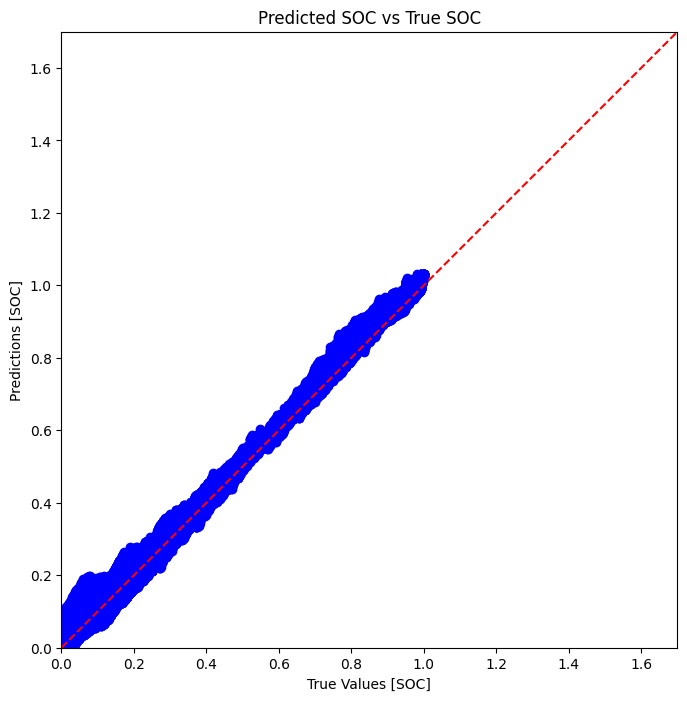

In [18]:
test_results = dnn_model.evaluate(test_features, test_labels, verbose=2)

# Generate predictions on the test set
test_predictions = dnn_model.predict(test_features).flatten()

# Plotting the real SOC vs. predicted SOC
plt.figure(figsize=(8, 8))
a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions, color='blue')  # Plot true vs. predicted
plt.xlabel('True Values [SOC]')
plt.ylabel('Predictions [SOC]')

# Draw a line representing perfect predictions (y = x)
lims = [0, 1.7]  # Adjust based on your SOC range
plt.xlim(lims)
plt.ylim(lims)
plt.plot(lims, lims, 'r--')  # Dashed red line for the ideal case

# Add title
plt.title('Predicted SOC vs True SOC')

# Show the plot
plt.show()

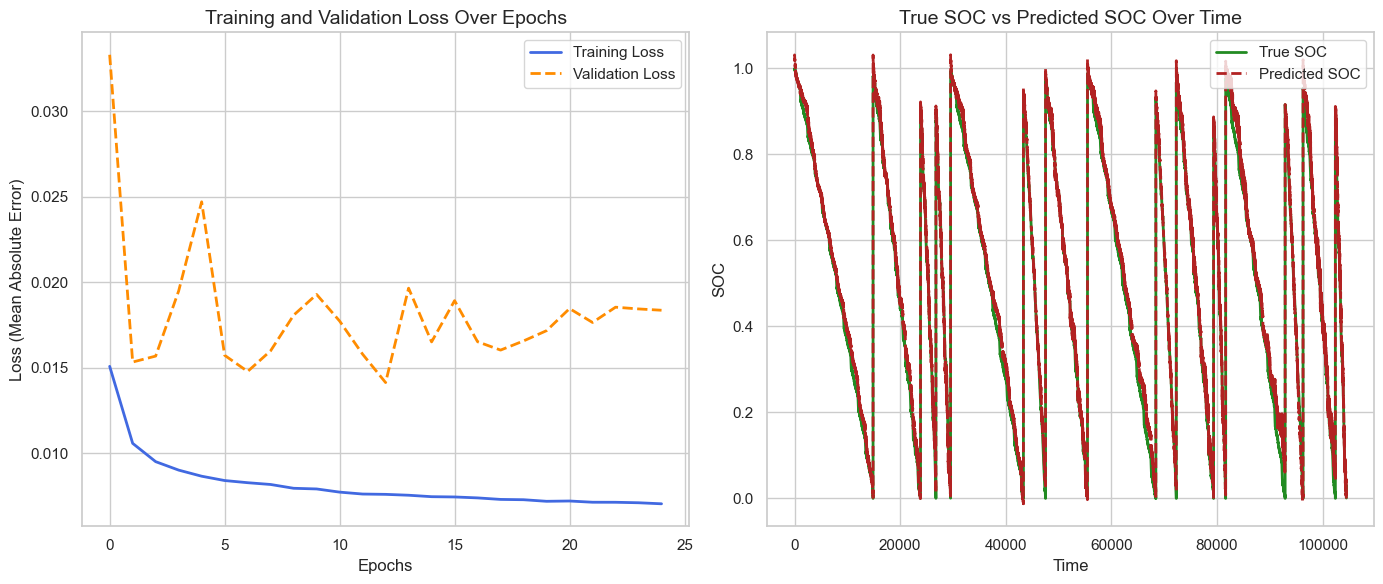

In [19]:
import seaborn as sns

# Set a modern theme using seaborn
sns.set(style="whitegrid")

# Plotting the loss over epochs
plt.figure(figsize=(14, 6))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='royalblue', linestyle='-', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linestyle='--', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Absolute Error)')
plt.title('Training and Validation Loss Over Epochs', fontsize=14)
plt.legend()
plt.grid(True)

# Prediction vs True SOC over time
plt.subplot(1, 2, 2)
plt.plot(test_labels, label='True SOC', color='forestgreen', linestyle='-', linewidth=2)
plt.plot(test_predictions, label='Predicted SOC', color='firebrick', linestyle='--', linewidth=2)
plt.xlabel('Time')
plt.ylabel('SOC')
plt.title('True SOC vs Predicted SOC Over Time', fontsize=14)
plt.legend()
plt.grid(True)

# Tight layout for better spacing
plt.tight_layout()

# Show the plots
plt.show()


In [20]:
from sklearn.metrics import r2_score

# Calculate R-squared
r2 = r2_score(test_labels, test_predictions)

print(f"R-squared: {r2:.2f}")

R-squared: 0.99


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, explained_variance_score

# True and predicted values
y_true = test_labels
y_pred = test_predictions

# Calculating various metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)
explained_variance = explained_variance_score(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R-squared: {r2:.3f}")
print(f"Explained Variance: {explained_variance:.3f}")


MAE: 0.023
MSE: 0.001
RMSE: 0.028
R-squared: 0.990
Explained Variance: 0.995


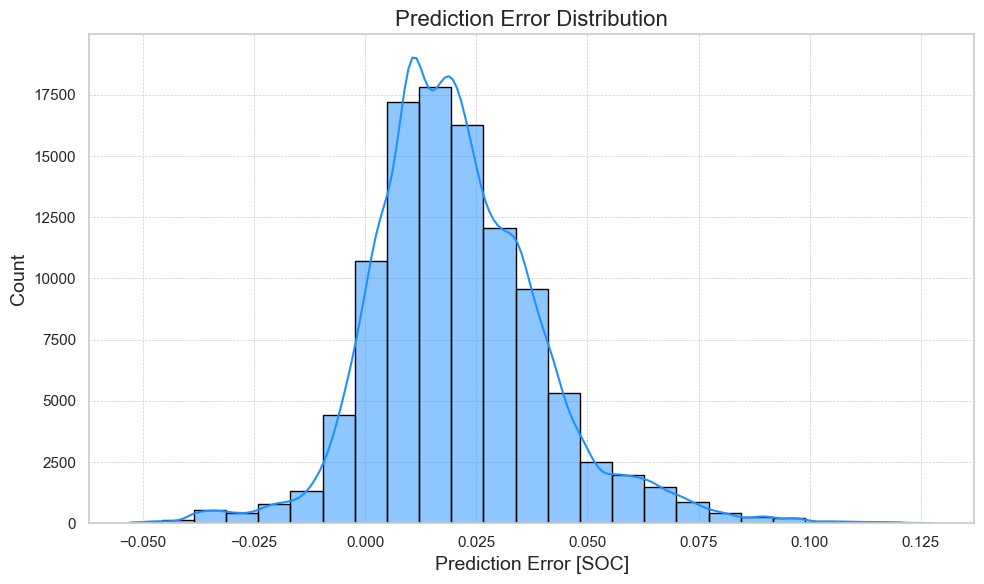

In [22]:

# Set a modern theme using Seaborn
sns.set(style="whitegrid")

# Calculate the prediction errors
error = test_predictions - test_labels

# Plotting the histogram of prediction errors
plt.figure(figsize=(10, 6))

# Using Seaborn's histogram plotting function for enhanced style
sns.histplot(error, bins=25, kde=True, color='dodgerblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Prediction Error [SOC]', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Prediction Error Distribution', fontsize=16)

# Enhancing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


In [23]:
import plotly.graph_objects as go

cycle_num = 0
steps_num = 100000
step_index = np.arange(cycle_num*steps_num, (cycle_num+1)*steps_num)

fig = go.Figure()
fig.add_trace(go.Scatter(x=step_index, y=test_predictions[cycle_num*steps_num:(cycle_num+1)*steps_num],
                    mode='lines', name='SOC Predicted'))
fig.add_trace(go.Scatter(x=step_index, y=test_labels[cycle_num*steps_num:(cycle_num+1)*steps_num],
                    mode='lines', name='SOC Actual'))
fig.add_trace(go.Scatter(x=step_index, y=lg_test_norm['Temperature'][cycle_num*steps_num:(cycle_num+1)*steps_num],
                    mode='lines', name='Temperature'))
fig.update_layout(title='Result on Test Dataset',
                  xaxis_title='Step',
                  yaxis_title='SOC Percentage')
fig.show()

In [24]:
# Training MAE
train_mae = history.history['mae']

# Validation MAE
val_mae = history.history['val_mae']


In [25]:
# Assuming the previous code has been executed and the following variables are available:
# train_mae, val_mae, test_mae

# Create a DataFrame to store the results
results_df = pd.DataFrame({
    "Epoch": range(1, len(train_mae) + 1),
    "Training MAE": train_mae,
    "Validation MAE": val_mae
})

# Display the final MAE values for Training, Validation, and Test
final_results_df = pd.DataFrame({
    "Metric": ["Training MAE", "Validation MAE", "Test MAE"],
    "Value": [train_mae[-1], val_mae[-1], mae]
})

# Print the results table
print("Training and Validation MAE per Epoch:")
print(results_df)

print("\nFinal MAE Results:")
print(final_results_df)


Training and Validation MAE per Epoch:
    Epoch  Training MAE  Validation MAE
0       1      0.015092        0.033301
1       2      0.010592        0.015343
2       3      0.009522        0.015692
3       4      0.009028        0.019497
4       5      0.008671        0.024709
5       6      0.008418        0.015738
6       7      0.008292        0.014793
7       8      0.008188        0.016002
8       9      0.007966        0.018082
9      10      0.007927        0.019294
10     11      0.007741        0.017740
11     12      0.007629        0.015802
12     13      0.007611        0.014144
13     14      0.007560        0.019660
14     15      0.007475        0.016520
15     16      0.007459        0.018932
16     17      0.007404        0.016530
17     18      0.007315        0.016042
18     19      0.007297        0.016578
19     20      0.007205        0.017178
20     21      0.007222        0.018469
21     22      0.007150        0.017656
22     23      0.007148        0.018550
2